In [3]:
import pandas as pd
import numpy as np

**Part A – Data Wrangling & Exploration (Pandas & NumPy) :**

In [6]:
deliveries=pd.read_csv(r"C:\Users\Ansh Verma\Downloads\deliveries.csv\deliveries.csv")
matches=pd.read_csv(r"C:\Users\Ansh Verma\Downloads\matches.csv")


In [5]:
ipl = deliveries.merge(matches,left_on='match_id',right_on='id',how='left')
print("Shape of Merged Data:",ipl.shape)
print("Columns in Merged Dataset:\n",ipl.columns)
print("Datatypes in Merged DataSet:\n",ipl.dtypes)
print("Seasons Covered:", matches['season'].nunique())

Shape of Merged Data: (150460, 39)
Columns in Merged Dataset:
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batsman', 'non_striker', 'bowler', 'is_super_over', 'wide_runs',
       'bye_runs', 'legbye_runs', 'noball_runs', 'penalty_runs',
       'batsman_runs', 'extra_runs', 'total_runs', 'player_dismissed',
       'dismissal_kind', 'fielder', 'id', 'season', 'city', 'date', 'team1',
       'team2', 'toss_winner', 'toss_decision', 'result', 'dl_applied',
       'winner', 'win_by_runs', 'win_by_wickets', 'player_of_match', 'venue',
       'umpire1', 'umpire2', 'umpire3'],
      dtype='object')
Datatypes in Merged DataSet:
 match_id             int64
inning               int64
batting_team        object
bowling_team        object
over                 int64
ball                 int64
batsman             object
non_striker         object
bowler              object
is_super_over        int64
wide_runs            int64
bye_runs             int64
legbye_

In [23]:
missing = ipl.isnull().sum()
ipl['player_dismissed'] = ipl['player_dismissed'].fillna('Not Dismissed')
ipl['dismissal_kind'] = ipl['dismissal_kind'].fillna('not out')
ipl['fielder'] = ipl['fielder'].fillna('No Fielder')
ipl['city'] = ipl['city'].fillna('Unknown')
ipl['winner'] = ipl['winner'].fillna('No Result')
ipl['player_of_match'] = ipl['player_of_match'].fillna('No Award')
ipl['umpire1'] = ipl['umpire1'].fillna('Unknown Umpire')
ipl['umpire2'] = ipl['umpire2'].fillna('Unknown Umpire')
ipl['umpire3'] = ipl['umpire3'].fillna('No Third Umpire')
print(ipl.isnull().sum())

match_id            0
inning              0
batting_team        0
bowling_team        0
over                0
ball                0
batsman             0
non_striker         0
bowler              0
is_super_over       0
wide_runs           0
bye_runs            0
legbye_runs         0
noball_runs         0
penalty_runs        0
batsman_runs        0
extra_runs          0
total_runs          0
player_dismissed    0
dismissal_kind      0
fielder             0
id                  0
season              0
city                0
date                0
team1               0
team2               0
toss_winner         0
toss_decision       0
result              0
dl_applied          0
winner              0
win_by_runs         0
win_by_wickets      0
player_of_match     0
venue               0
umpire1             0
umpire2             0
umpire3             0
dtype: int64


In [30]:
deliveries['total_runs'] = (deliveries['batsman_runs'] +deliveries['extra_runs'])

In [32]:
deliveries['is_boundary'] = np.where(deliveries['batsman_runs'] >= 4,'boundary','non-boundary')
deliveries[['batsman_runs','is_boundary']].head()

,batsman_runs,is_boundary
0,0,non-boundary
1,0,non-boundary
2,4,boundary
3,0,non-boundary
4,0,non-boundary


In [33]:
deliveries['over_number'] = deliveries['over']
def phase(over):
    if over <= 6:
        return 'Powerplay'
    elif over <= 15:
        return 'Middle'
    else:
        return 'Death'

deliveries['over_phase'] = deliveries['over_number'].apply(phase)

deliveries[['over_number','over_phase']].head()

,over_number,over_phase
0,1,Powerplay
1,1,Powerplay
2,1,Powerplay
3,1,Powerplay
4,1,Powerplay


In [35]:
matches['date'] = pd.to_datetime(
    matches['date'],
    format='%d-%m-%Y'
)

matches['year'] = matches['date'].dt.year
matches['month'] = matches['date'].dt.month

matches[['date','year','month']].head()

,date,year,month
0,2017-04-05,2017,4
1,2017-04-06,2017,4
2,2017-04-07,2017,4
3,2017-04-08,2017,4
4,2017-04-08,2017,4


In [37]:
top_batsmen = deliveries.groupby('batsman')['batsman_runs'].sum()

top_batsmen = top_batsmen.sort_values(
    ascending=False
).head(5)

print(top_batsmen)

batsman
SK Raina     4548
V Kohli      4423
RG Sharma    4207
G Gambhir    4132
DA Warner    4014
Name: batsman_runs, dtype: int64


In [38]:
bowler_stats = deliveries.groupby('bowler').agg(
    balls=('ball','count'),
    runs=('total_runs','sum')
)

bowler_stats = bowler_stats[
    bowler_stats['balls'] >= 500
]

bowler_stats['overs'] = bowler_stats['balls'] / 6

bowler_stats['economy_rate'] = np.divide(
    bowler_stats['runs'],
    bowler_stats['overs']
)

economy = bowler_stats.sort_values(
    'economy_rate'
)

economy[['economy_rate']].head()

,economy_rate
bowler,
SP Narine,6.395706
R Ashwin,6.490886
DW Steyn,6.600278
A Kumble,6.646999
M Muralitharan,6.698292


In [39]:
season_team = matches.groupby(
    ['season','winner']
).size().reset_index(name='wins')

total_matches = matches.groupby(
    'season'
).size().reset_index(name='total_matches')

season_team = season_team.merge(
    total_matches,
    on='season'
)

season_team['win_percentage'] = (
    season_team['wins'] /
    season_team['total_matches']
) * 100

highest_wp = season_team.loc[
    season_team.groupby('season')['win_percentage'].idxmax()
]

highest_wp

,season,winner,wins,total_matches,win_percentage
6,2008,Rajasthan Royals,13,58,22.413793
10,2009,Delhi Daredevils,10,57,17.543860
21,2010,Mumbai Indians,11,60,18.333333
24,2011,Chennai Super Kings,11,73,15.068493
38,2012,Kolkata Knight Riders,12,74,16.216216
47,2013,Mumbai Indians,13,76,17.105263
54,2014,Kings XI Punjab,12,60,20.000000
60,2015,Chennai Super Kings,10,59,16.949153
75,2016,Sunrisers Hyderabad,11,60,18.333333
80,2017,Mumbai Indians,12,59,20.338983


**Part B – Visual Analysis & Pattern Discovery (Matplotlib & Seaborn) :**

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
sns.set_style("whitegrid")

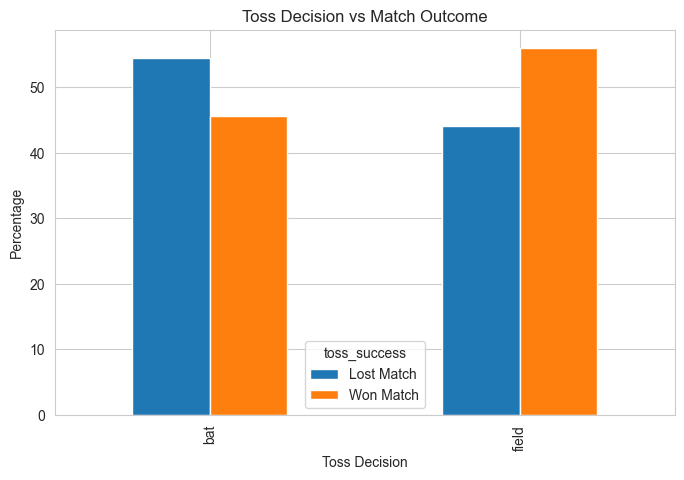

In [14]:
matches['toss_success'] = np.where(
    matches['toss_winner'] == matches['winner'],
    'Won Match',
    'Lost Match'
)

toss_analysis = pd.crosstab(
    matches['toss_decision'],
    matches['toss_success'],
    normalize='index'
) * 100

toss_analysis.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Toss Decision vs Match Outcome')
plt.ylabel('Percentage')
plt.xlabel('Toss Decision')
plt.show()

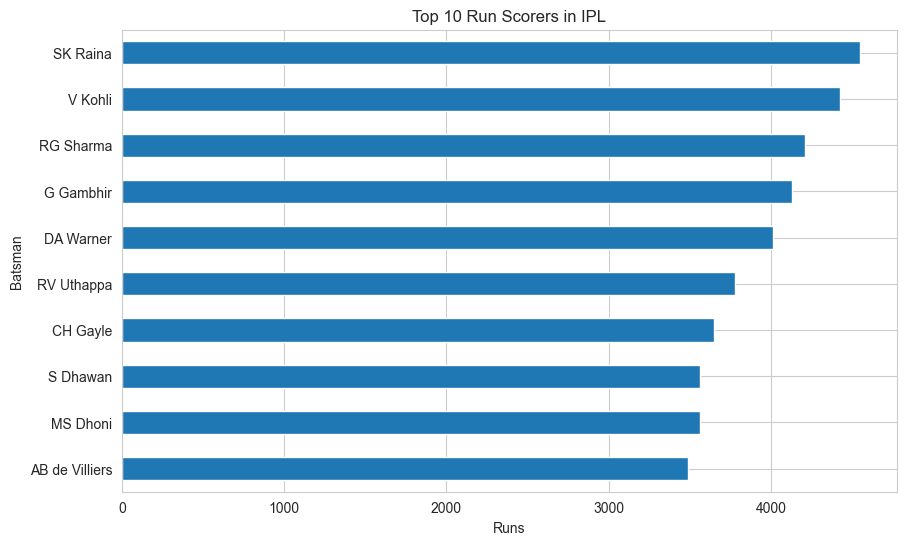

In [17]:
top10 = deliveries.groupby('batsman')['batsman_runs'].sum()
top10 = top10.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
top10.sort_values().plot(
    kind='barh'
)
plt.title("Top 10 Run Scorers in IPL")
plt.xlabel("Runs")
plt.ylabel("Batsman")
plt.show()

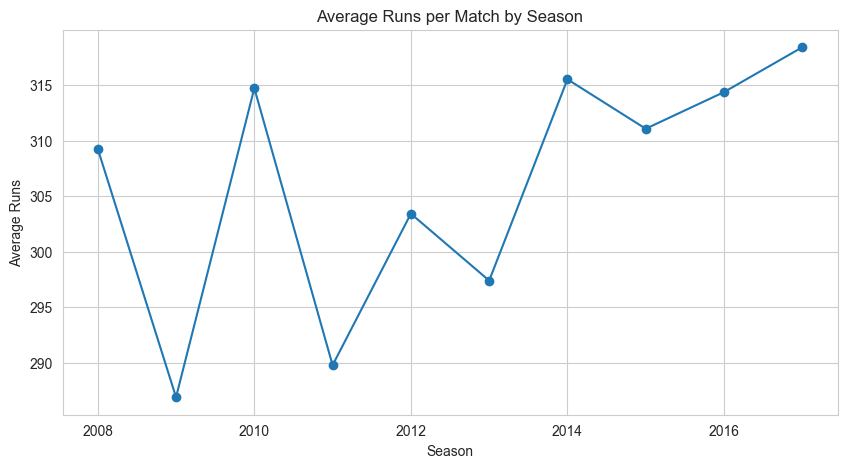

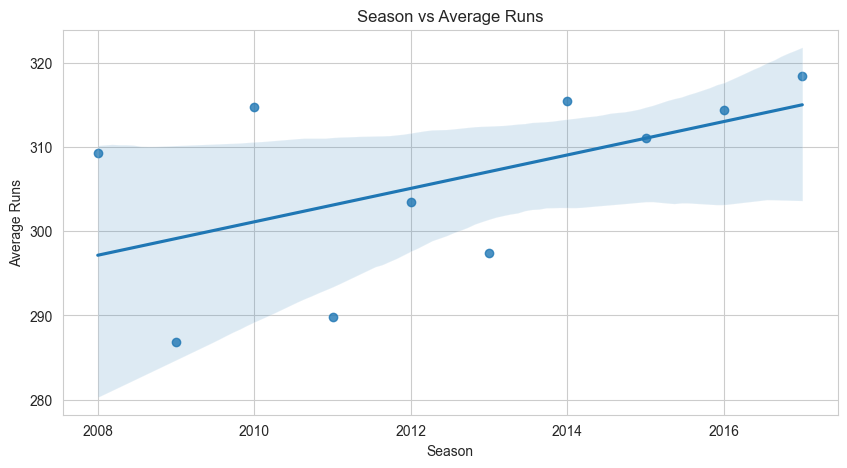

In [18]:
deliveries['total_runs_scored'] = (
    deliveries['batsman_runs'] +
    deliveries['extra_runs']
)
match_runs = deliveries.groupby(
    'match_id'
)['total_runs_scored'].sum().reset_index()

match_runs = match_runs.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)
season_avg = match_runs.groupby(
    'season'
)['total_runs_scored'].mean()

plt.figure(figsize=(10,5))
season_avg.plot(
    marker='o'
)
plt.title("Average Runs per Match by Season")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.grid(True)
plt.show()

season_df = season_avg.reset_index()
plt.figure(figsize=(10,5))
sns.regplot(
    data=season_df,
    x='season',
    y='total_runs_scored'
)
plt.title("Season vs Average Runs")
plt.xlabel("Season")
plt.ylabel("Average Runs")
plt.show()

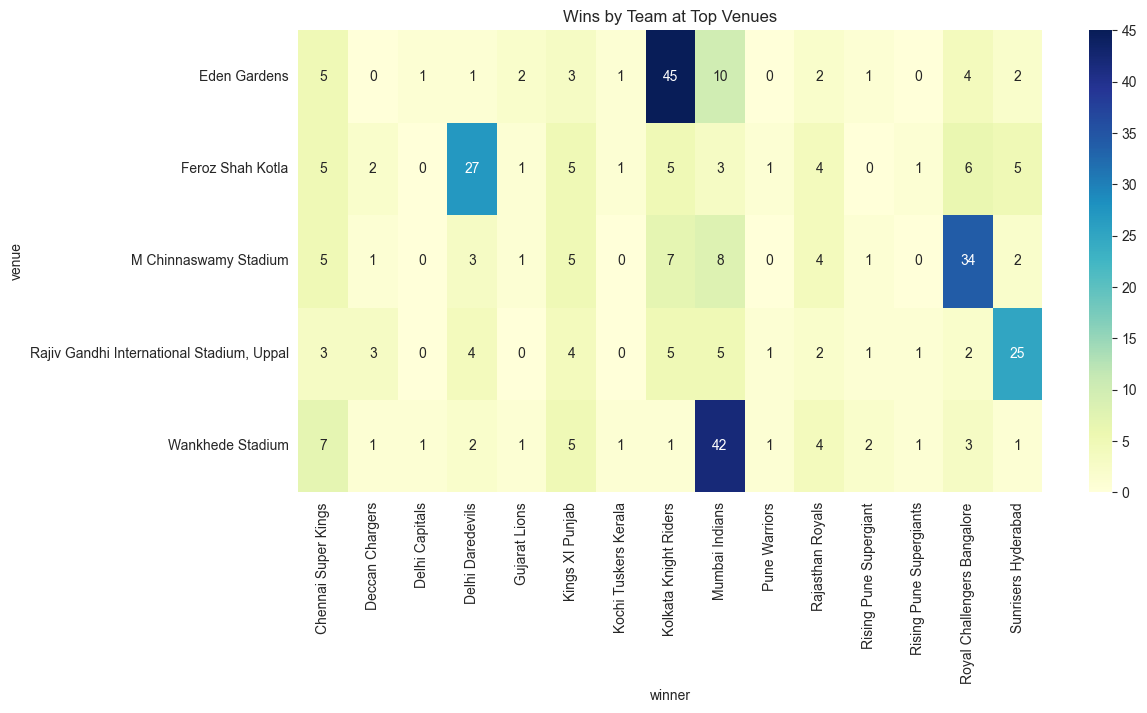

In [8]:
top5_venues = matches['venue'].value_counts().head(5)
top_venues = top5_venues.index
venue_data = matches[
    matches['venue'].isin(top_venues)
]
heat = pd.crosstab(
    venue_data['venue'],
    venue_data['winner']
)
plt.figure(figsize=(12,6))
sns.heatmap(
    venue_wins,
    annot=True,
    fmt='d',
    cmap='YlGnBu'
)
plt.title("Wins by Team at Top Venues")
plt.show()

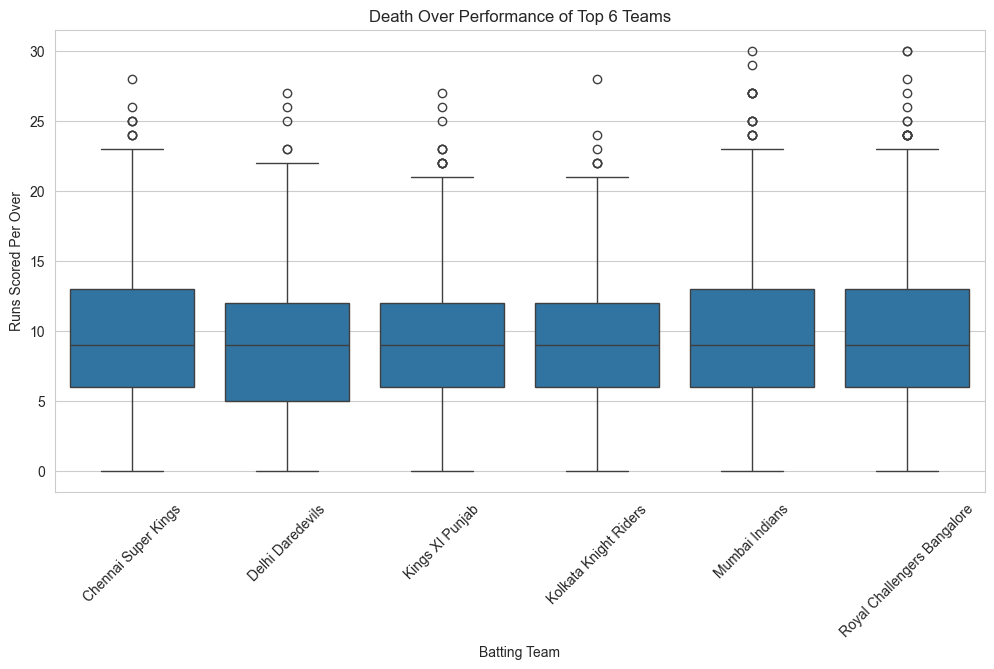

In [23]:
deliveries['total_runs_scored'] = (
    deliveries['batsman_runs'] +
    deliveries['extra_runs']
)
death = deliveries[
    deliveries['over'].between(16, 20)
]
top6_teams = death.groupby(
    'batting_team'
)['total_runs_scored'].sum().sort_values(
    ascending=False
).head(6)
top6_team_names = top6_teams.index
death_top = death[
    death['batting_team'].isin(top6_team_names)
]
over_runs = death_top.groupby(
    ['batting_team', 'match_id', 'over']
)['total_runs_scored'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.boxplot(
    data=over_runs,
    x='batting_team',
    y='total_runs_scored'
)
plt.title("Death Over Performance of Top 6 Teams")
plt.xlabel("Batting Team")
plt.ylabel("Runs Scored Per Over")
plt.xticks(rotation=45)
plt.show()

**SOME OTHER ANANLYSIS:**

**BATTING ANALYSIS:**

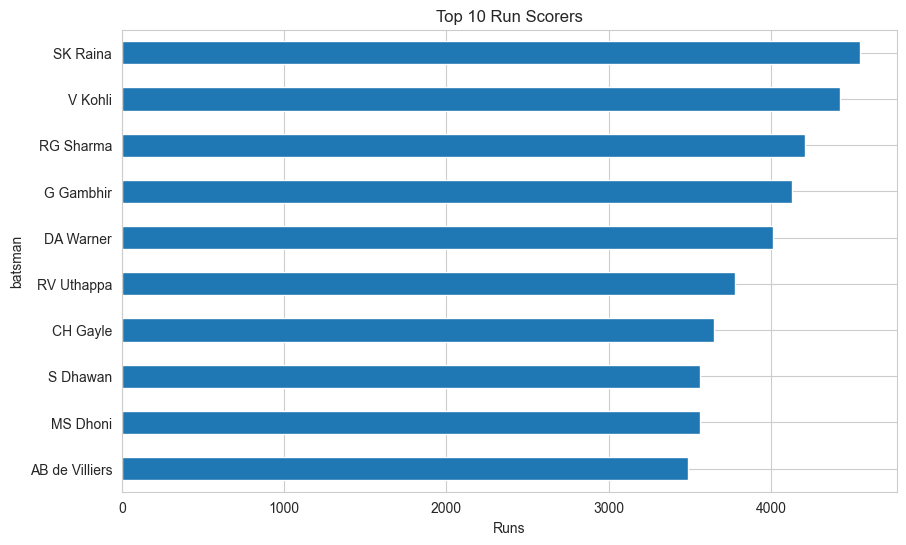

In [10]:
top10 = deliveries.groupby('batsman')['batsman_runs'].sum()
top10 = top10.sort_values(
    ascending=False
).head(10)
plt.figure(figsize=(10,6))
top10.sort_values().plot(kind='barh')
plt.title("Top 10 Run Scorers")
plt.xlabel("Runs")
plt.show()

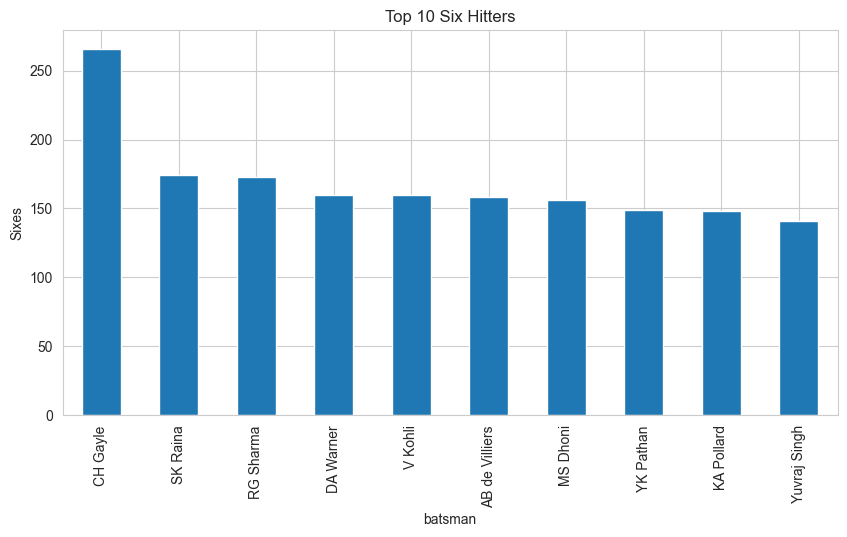

In [11]:
sixes = deliveries[
    deliveries['batsman_runs'] == 6
]
top_sixes = sixes.groupby(
    'batsman'
).size().sort_values(
    ascending=False
).head(10)
top_sixes.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Top 10 Six Hitters")
plt.ylabel("Sixes")
plt.show()

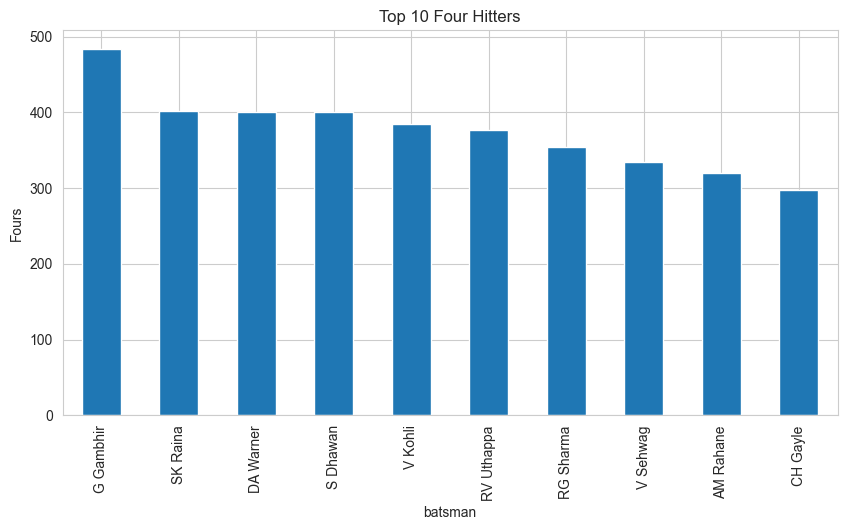

In [12]:
fours = deliveries[
    deliveries['batsman_runs'] == 4
]
top_fours = fours.groupby(
    'batsman'
).size().sort_values(
    ascending=False
).head(10)
top_fours.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Top 10 Four Hitters")
plt.ylabel("Fours")
plt.show()

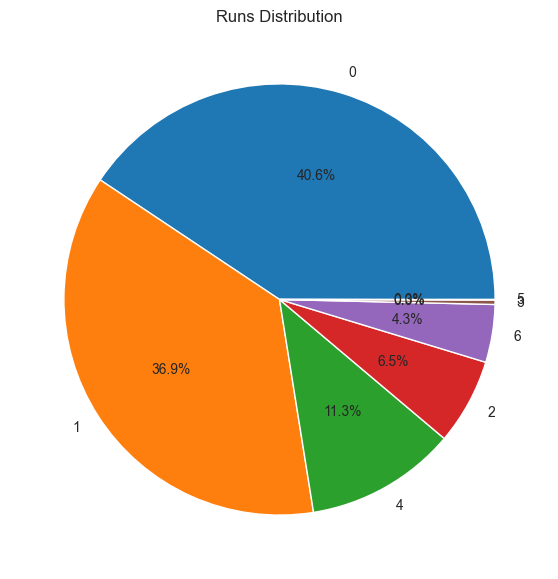

In [13]:
boundary = deliveries['batsman_runs'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(
    boundary,
    labels=boundary.index,
    autopct='%1.1f%%'
)
plt.title("Runs Distribution")
plt.show()

**BOWLING ANALYSIS:**

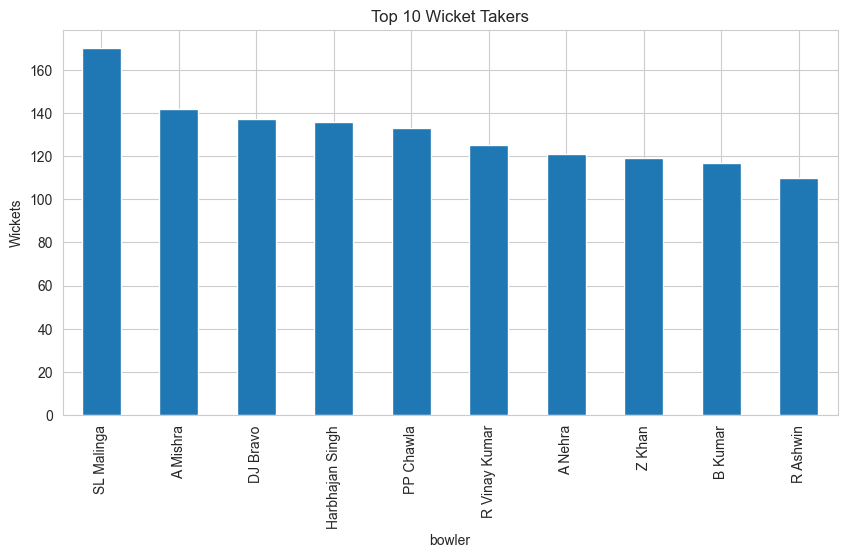

In [14]:
wickets = deliveries[
    deliveries['player_dismissed'].notna()
]
top_bowlers = wickets.groupby(
    'bowler'
).size().sort_values(
    ascending=False
).head(10)
top_bowlers.plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Top 10 Wicket Takers")
plt.ylabel("Wickets")
plt.show()

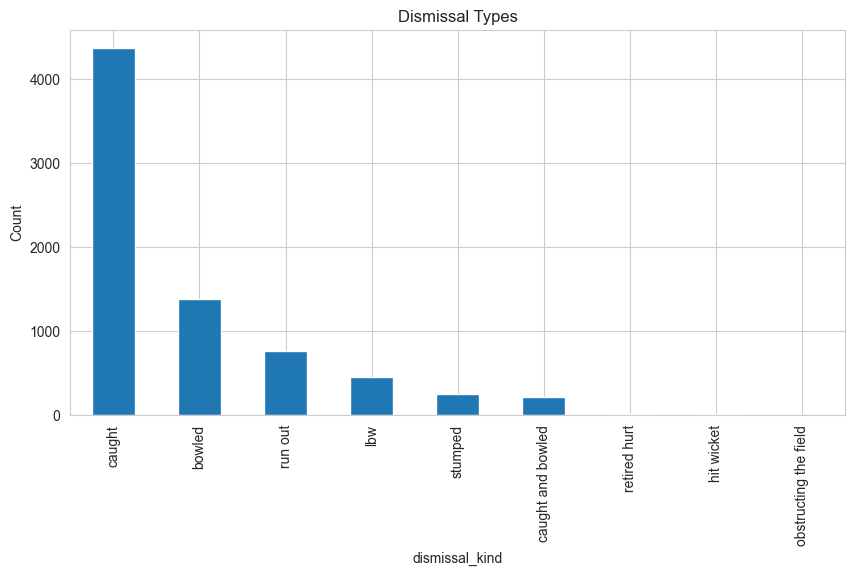

In [15]:
dismissal = deliveries[
    deliveries['dismissal_kind'].notna()
]
dismissal['dismissal_kind'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)
plt.title("Dismissal Types")
plt.ylabel("Count")
plt.show()

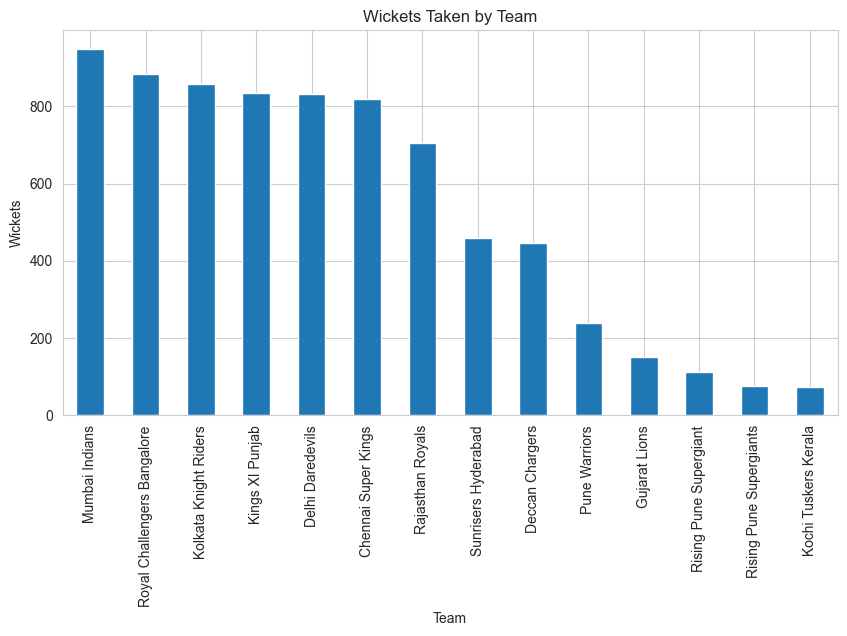

In [4]:
team_wickets = deliveries[
    deliveries['player_dismissed'].notna()
].groupby(
    'bowling_team'
)['player_dismissed'].count().sort_values(
    ascending=False
)

plt.figure(figsize=(10,5))
team_wickets.plot(kind='bar')
plt.title('Wickets Taken by Team')
plt.xlabel('Team')
plt.ylabel('Wickets')
plt.xticks(rotation=90)
plt.show()

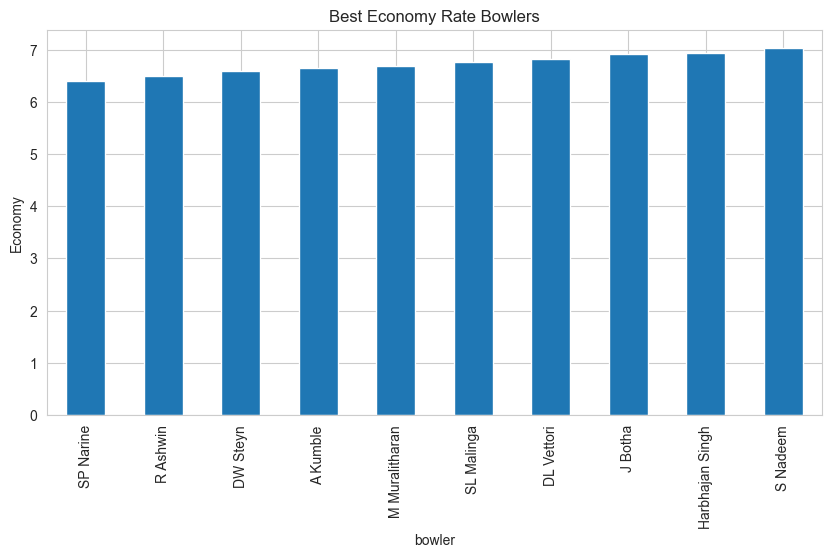

In [18]:
deliveries['total_runs_scored'] = (
    deliveries['batsman_runs'] +
    deliveries['extra_runs']
)

eco = deliveries.groupby('bowler').agg(
    balls=('ball','count'),
    runs=('total_runs_scored','sum')
)

eco = eco[
    eco['balls'] >= 500
]

eco['overs'] = eco['balls'] / 6

eco['economy'] = eco['runs'] / eco['overs']

eco = eco.sort_values(
    'economy'
).head(10)

eco['economy'].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Best Economy Rate Bowlers")
plt.ylabel("Economy")
plt.show()

**Season Analysis:**

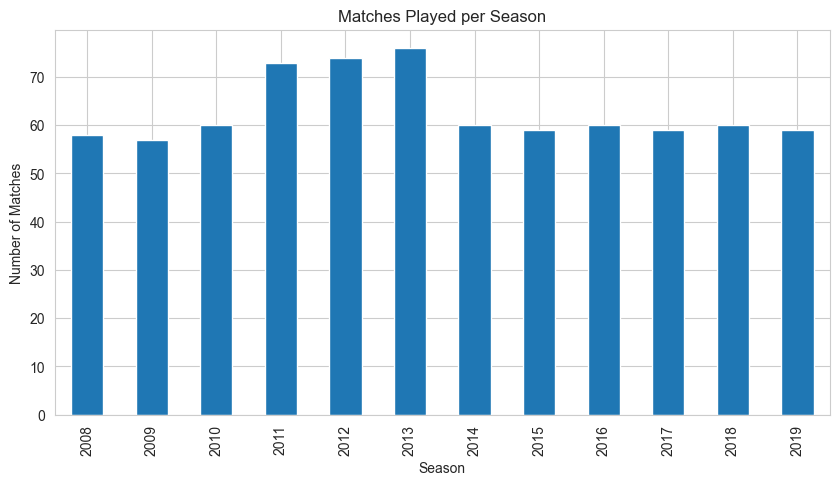

In [31]:
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(10,5))

season_matches.plot(
    kind='bar'
)

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.show()

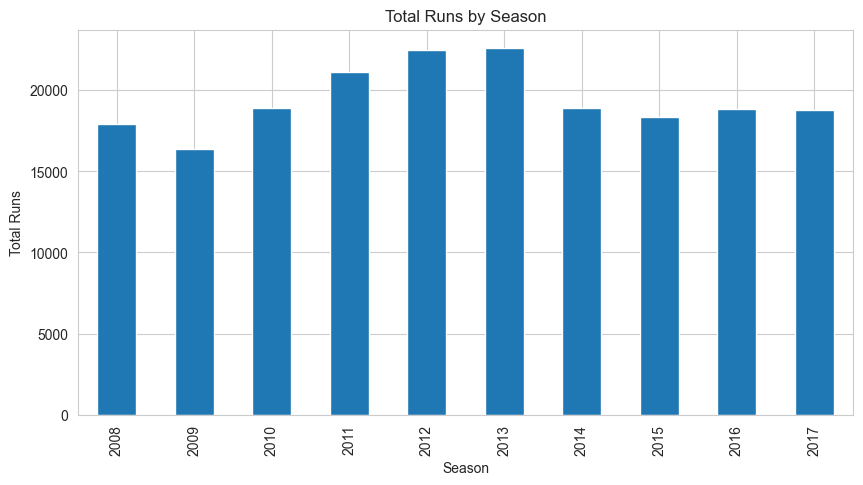

In [22]:
deliveries['total_runs_scored'] = (
    deliveries['batsman_runs'] +
    deliveries['extra_runs']
)
match_runs = deliveries.groupby(
    'match_id'
)['total_runs_scored'].sum().reset_index()
match_runs = match_runs.merge(
    matches[['id', 'season']],
    left_on='match_id',
    right_on='id'
)
season_total = match_runs.groupby(
    'season'
)['total_runs_scored'].sum()

plt.figure(figsize=(10,5))

season_total.plot(
    kind='bar'
)

plt.title("Total Runs by Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")

plt.show()

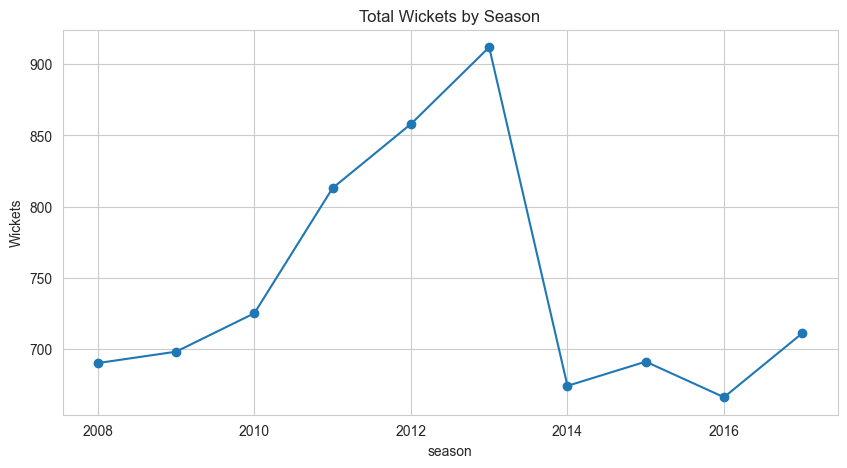

In [23]:
wickets = deliveries[
    deliveries['player_dismissed'].notna()
]

season_wickets = wickets.groupby(
    'match_id'
).size().reset_index(name='wickets')

season_wickets = season_wickets.merge(
    matches[['id','season']],
    left_on='match_id',
    right_on='id'
)

season_wickets.groupby(
    'season'
)['wickets'].sum().plot(
    marker='o',
    figsize=(10,5)
)

plt.title("Total Wickets by Season")
plt.ylabel("Wickets")
plt.show()

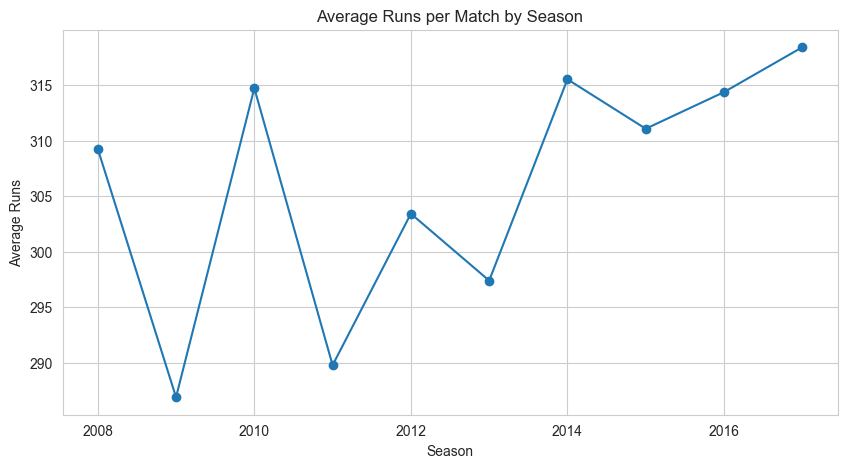

In [38]:
avg_runs = match_runs.groupby(
    'season'
)['total_runs_scored'].mean()

plt.figure(figsize=(10,5))
avg_runs.plot(
    kind='line',
    marker='o'
)

plt.title('Average Runs per Match by Season')
plt.xlabel('Season')
plt.ylabel('Average Runs')
plt.grid(True)
plt.show()

**TEAM ANALYSIS:**

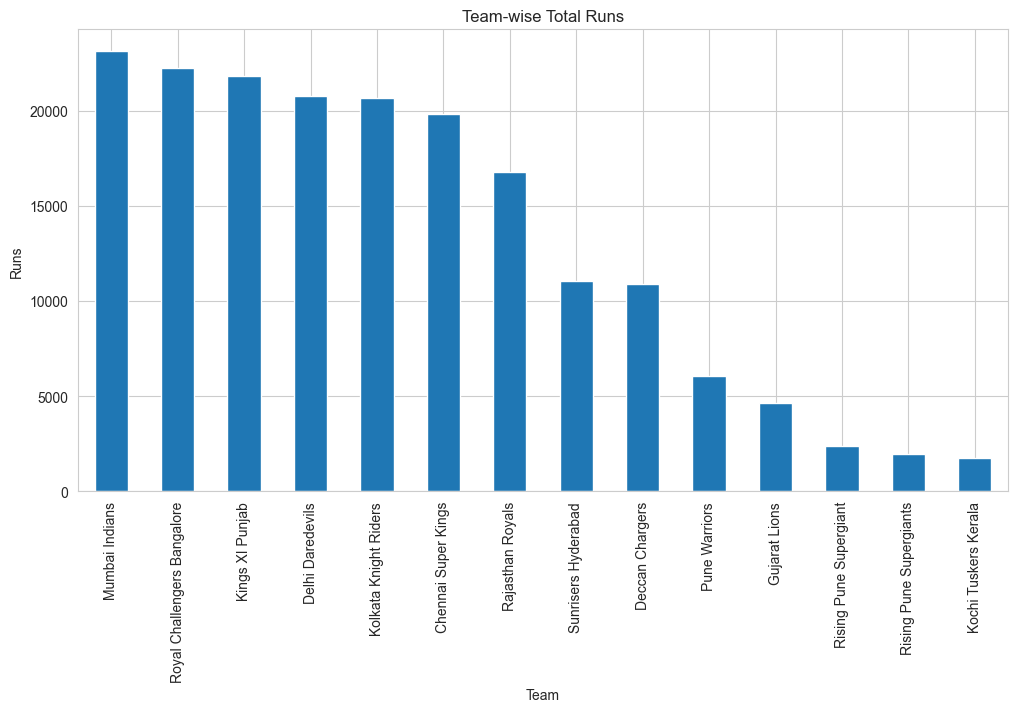

In [24]:
team_runs = deliveries.groupby(
    'batting_team'
)['batsman_runs'].sum().sort_values(
    ascending=False
)

plt.figure(figsize=(12,6))

team_runs.plot(kind='bar')

plt.title("Team-wise Total Runs")
plt.xlabel("Team")
plt.ylabel("Runs")

plt.xticks(rotation=90)

plt.show()

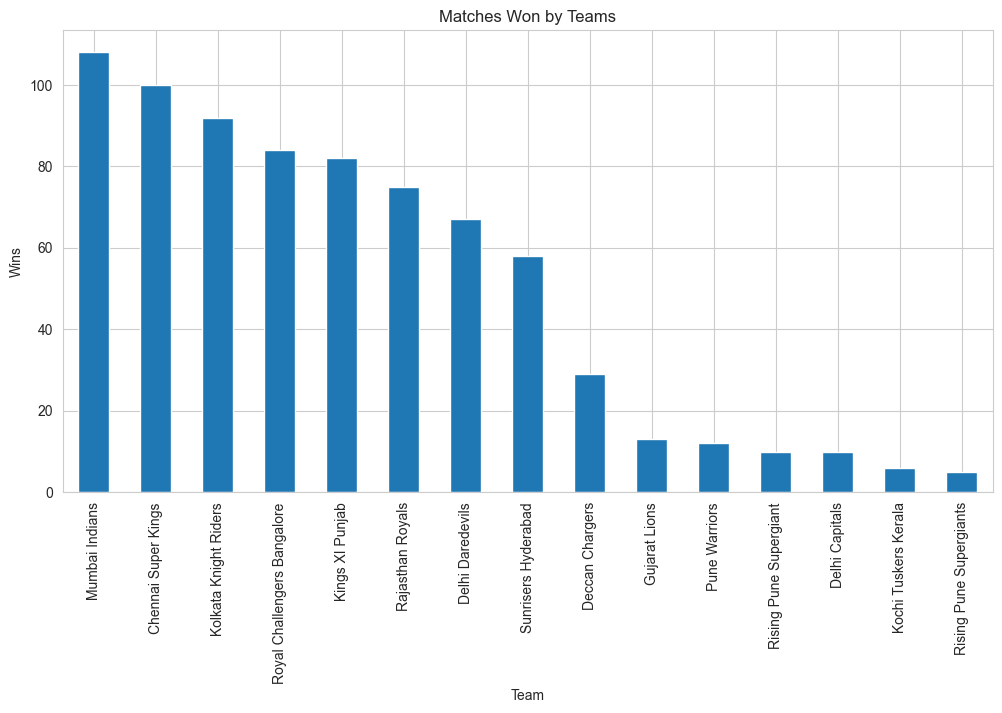

In [25]:
team_wins = matches['winner'].value_counts()

plt.figure(figsize=(12,6))

team_wins.plot(kind='bar')

plt.title("Matches Won by Teams")
plt.xlabel("Team")
plt.ylabel("Wins")

plt.xticks(rotation=90)

plt.show()

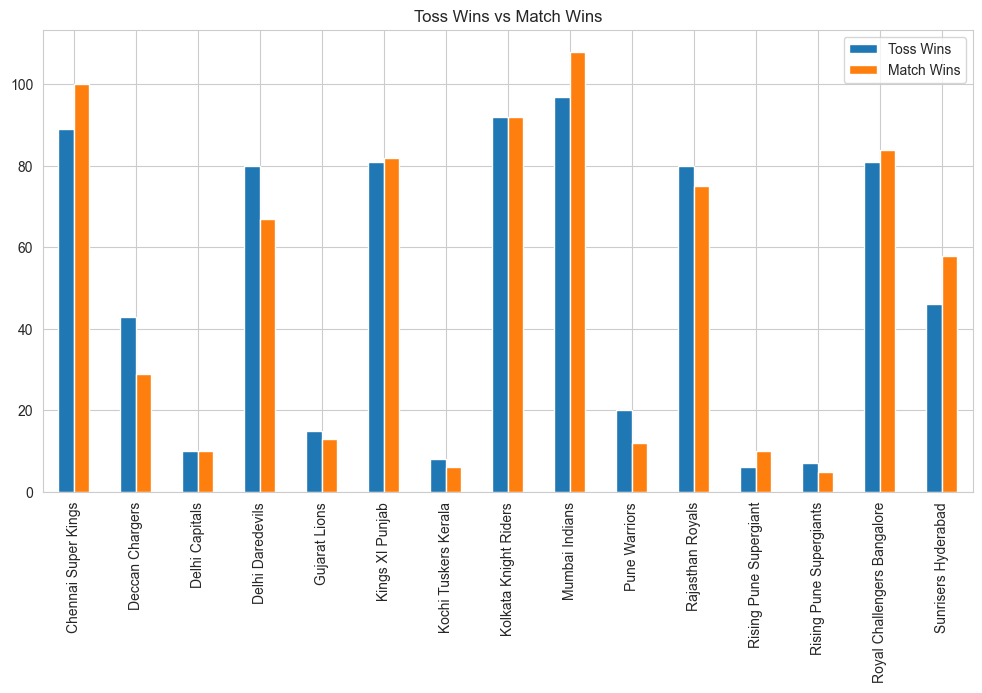

In [27]:
toss = matches['toss_winner'].value_counts()
wins = matches['winner'].value_counts()

compare = pd.DataFrame({
    'Toss Wins': toss,
    'Match Wins': wins
}).fillna(0)

compare.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Toss Wins vs Match Wins")

plt.xticks(rotation=90)

plt.show()

**MATCHES ANALYSIS:**

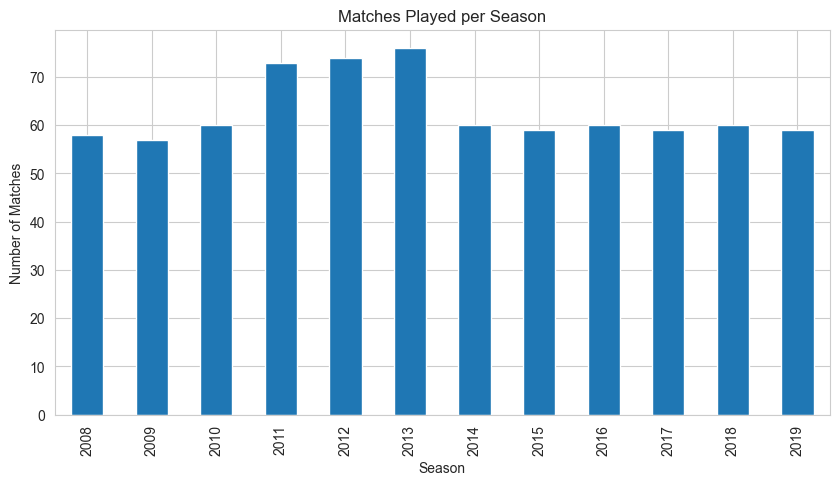

In [30]:
season_matches = matches['season'].value_counts().sort_index()

plt.figure(figsize=(10,5))

season_matches.plot(
    kind='bar'
)

plt.title("Matches Played per Season")
plt.xlabel("Season")
plt.ylabel("Number of Matches")

plt.show()

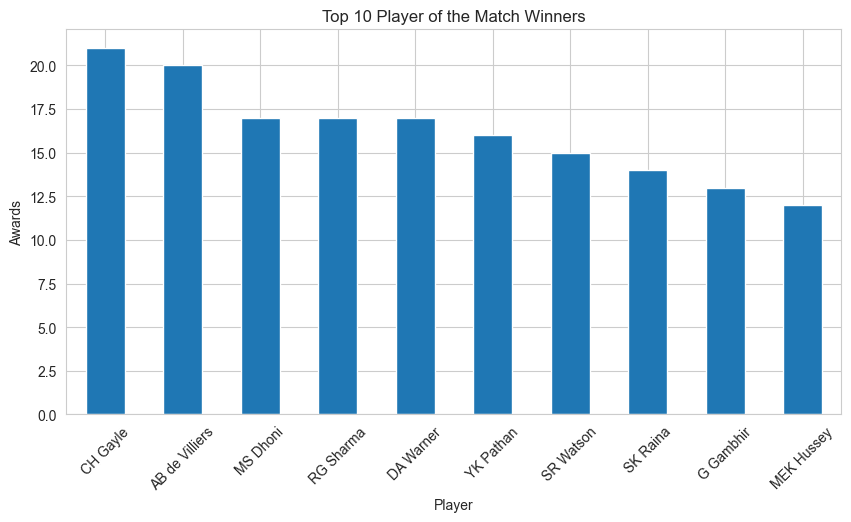

In [32]:
top_players = matches[
    'player_of_match'
].value_counts().head(10)

plt.figure(figsize=(10,5))

top_players.plot(
    kind='bar'
)

plt.title("Top 10 Player of the Match Winners")
plt.xlabel("Player")
plt.ylabel("Awards")

plt.xticks(rotation=45)

plt.show()

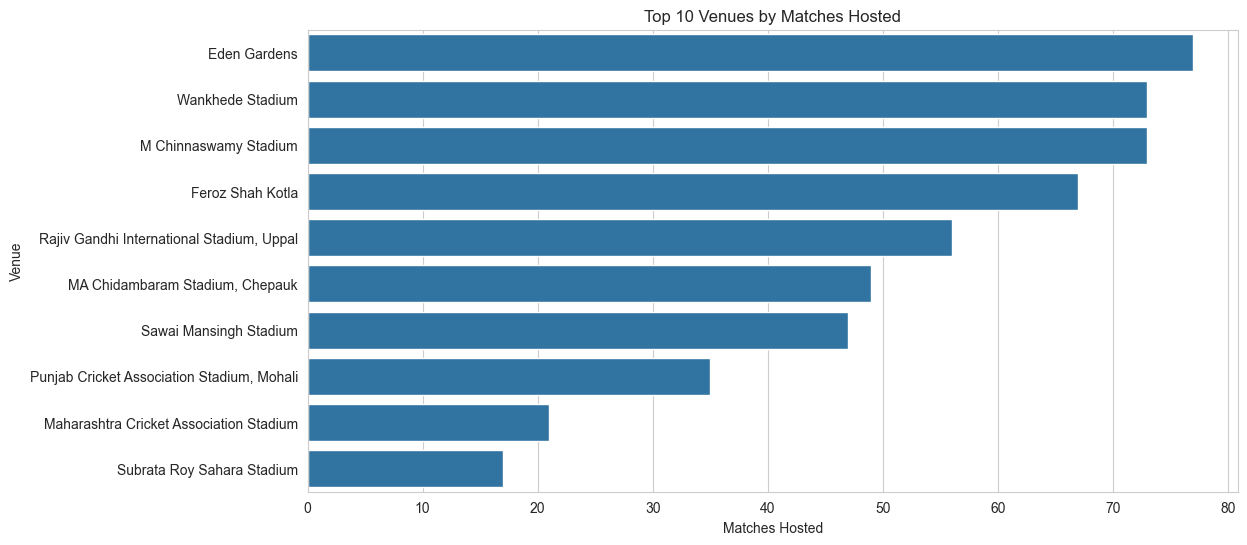

In [33]:
import seaborn as sns

top_venues = matches[
    'venue'
].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_venues.values,
    y=top_venues.index
)

plt.title("Top 10 Venues by Matches Hosted")
plt.xlabel("Matches Hosted")
plt.ylabel("Venue")

plt.show()

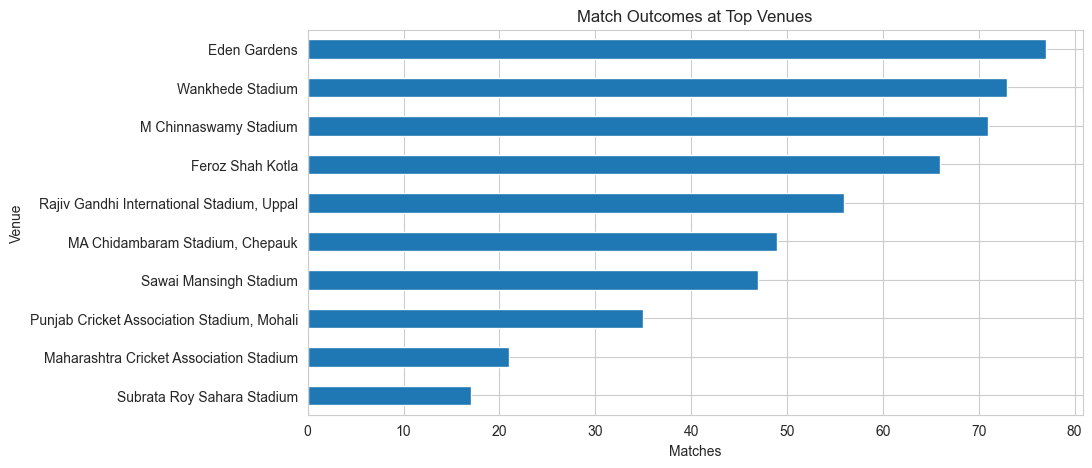

In [5]:
venue_matches = matches.groupby(
    'venue'
)['winner'].count().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
venue_matches.sort_values().plot(kind='barh')

plt.title('Match Outcomes at Top Venues')
plt.xlabel('Matches')
plt.ylabel('Venue')
plt.show()

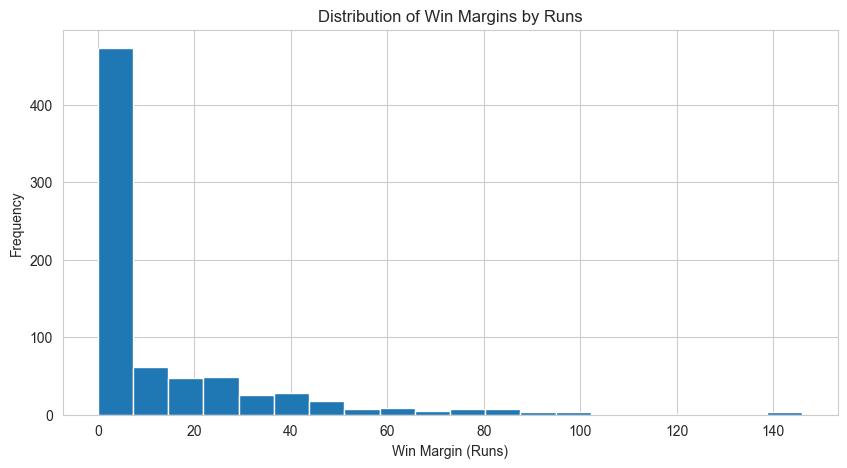

In [34]:
plt.figure(figsize=(10,5))

plt.hist(
    matches['win_by_runs'],
    bins=20
)

plt.title("Distribution of Win Margins by Runs")
plt.xlabel("Win Margin (Runs)")
plt.ylabel("Frequency")

plt.show()

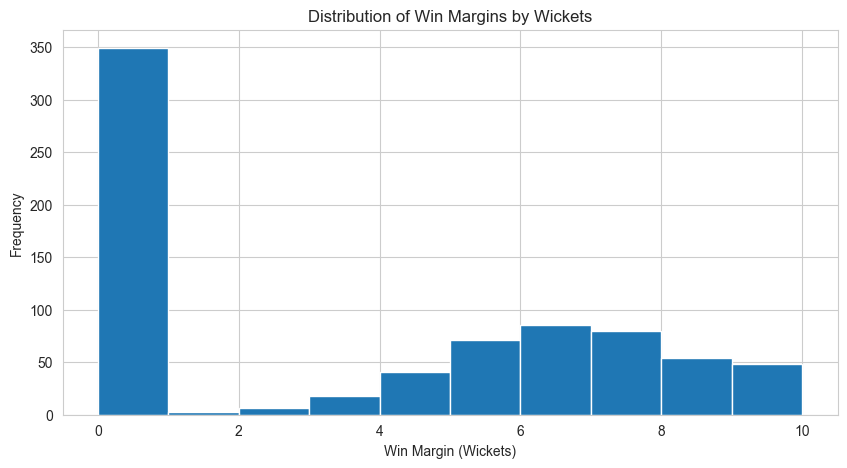

In [35]:
plt.figure(figsize=(10,5))

plt.hist(
    matches['win_by_wickets'],
    bins=10
)

plt.title("Distribution of Win Margins by Wickets")
plt.xlabel("Win Margin (Wickets)")
plt.ylabel("Frequency")

plt.show()